<a href="https://colab.research.google.com/github/lamonede/DeepLearning_Framework/blob/main/02_sft_mobilevit_vs_cnn_flowers102_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flowers102 실습: CNN vs MobileViT-XSmall SFT

## 실습 목표
- `Flowers102` 데이터셋에서 `from-scratch CNN`과 `pretrained MobileViT-XSmall`을 비교합니다.
- `pretrained model`을 불러오고, 구조를 확인하고, 분류 문제에 맞게 `supervised fine-tuning(지도학습 기반 미세조정)` 하는 흐름을 익힙니다.
- 왜 작은 데이터셋에서는 pretrained model이 유리할 수 있는지 확인합니다.

## 왜 이 실습이 중요한가?
- 최근 딥러닝 연구와 개발 워크플로우에서는, 모델을 완전히 무작위 초기화해서 처음부터 학습하기보다 `pretrained(사전학습) checkpoint`를 출발점으로 두고 `fine-tuning(미세조정)` 하는 접근이 매우 널리 사용됩니다.
- 이런 접근은 보통 처음부터 학습하는 것보다 더 적은 데이터, 더 적은 계산 자원, 더 짧은 시간으로 좋은 출발점을 얻기 쉽습니다.
- 여기서 `fine-tuning(미세조정)`이란, 이미 큰 데이터셋으로 학습된 모델 가중치를 가져온 뒤 현재 문제에 맞게 추가로 조금 더 학습시키는 과정을 의미합니다.
- 이번 실습은 이런 현대적인 워크플로우를 작은 이미지 분류 문제에 맞춰 직접 체험하는 데 목적이 있습니다.

## 오늘의 비교 대상
1. `CNN from scratch`
2. `MobileViT-XSmall pretrained + supervised fine-tuning`

> 이번 실습에서는 supervised fine-tuning에만 집중합니다.


In [ ]:
# 이 셀에서 하는 일:
# - Hugging Face Transformers와 Flowers102 로딩에 필요한 scipy를 설치합니다.
# - Colab에서 바로 실행할 수 있도록 필요한 패키지를 한 번에 준비합니다.

!pip install -q transformers accelerate scipy


In [ ]:
# 이 셀에서 하는 일:
# - 실습에 필요한 라이브러리를 불러옵니다.
# - 결과 재현을 위해 시드를 고정합니다.

# random은 파이썬 기본 난수 라이브러리로, 시드 고정에 사용합니다.
import random
# numpy는 수치 연산과 시드 고정에 사용합니다.
import numpy as np
# matplotlib는 샘플 이미지와 예측 결과를 시각화할 때 사용합니다.
import matplotlib.pyplot as plt

# torch는 Tensor 연산, 모델 학습, GPU 사용을 위한 핵심 라이브러리입니다.
import torch
# torchvision은 비전 데이터셋과 이미지 전처리 기능을 제공합니다.
import torchvision

# nn은 신경망 레이어와 손실 함수를 정의할 때 사용합니다.
from torch import nn
# DataLoader는 데이터를 배치 단위로 묶어 학습 루프에 전달할 때 사용합니다.
from torch.utils.data import DataLoader
# datasets는 Flowers102 로드, transforms는 이미지 전처리에 사용합니다.
from torchvision import datasets, transforms
# models는 torchvision이 제공하는 대표적인 사전 정의 모델을 불러올 때 사용합니다.
from torchvision import models
# AutoImageProcessor는 pretrained 모델에 맞는 전처리 정보를 불러오고,
# MobileViTForImageClassification은 pretrained MobileViT 분류 모델을 불러옵니다.
from transformers import AutoImageProcessor, MobileViTForImageClassification

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')


PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [ ]:
# 이 셀에서 하는 일:
# - 학습에 사용할 device를 정합니다.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용할 device: {device}')

if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')


사용할 device: cuda
GPU name: Tesla T4


## 1. Flowers102 데이터셋 준비

`Flowers102`는 Oxford에서 공개한 꽃 분류 데이터셋으로, 총 `102개 클래스`로 이루어져 있습니다.

이 데이터셋은 `torchvision`에서 공식 지원하며, transfer learning / fine-tuning 실습 예제로 자주 사용됩니다.

이번 실습에서는 데이터셋이 제공하는 공식 split을 그대로 사용합니다.
- `train`: 학습용
- `val`: 검증용
- `test`: 최종 평가용

이 데이터셋은 원래 학습용 이미지 수가 많지 않기 때문에, 추가로 subset을 만들지 않아도 pretrained model의 이점을 보기 좋은 편입니다.


In [ ]:
# 이 셀에서 하는 일:
# - Flowers102의 원본 split(train/val/test)을 다운로드합니다.
# - transform=None으로 먼저 불러와 원본 PIL 이미지를 확인할 준비를 합니다.

DATA_ROOT = './data'

raw_train_dataset = datasets.Flowers102(
    root=DATA_ROOT,
    split='train',
    download=True,
    transform=None,
)

raw_valid_dataset = datasets.Flowers102(
    root=DATA_ROOT,
    split='val',
    download=False,
    transform=None,
)

raw_test_dataset = datasets.Flowers102(
    root=DATA_ROOT,
    split='test',
    download=False,
    transform=None,
)

class_names = raw_train_dataset.classes

print(f'train 개수: {len(raw_train_dataset):,}')
print(f'valid 개수: {len(raw_valid_dataset):,}')
print(f'test 개수:  {len(raw_test_dataset):,}')
print(f'클래스 수: {len(class_names)}')


100%|██████████| 345M/345M [00:13<00:00, 25.2MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.86MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 39.1MB/s]

train 개수: 1,020
valid 개수: 1,020
test 개수:  6,149
클래스 수: 102


## 2. 원본 샘플 확인

전처리를 적용하기 전에, 실제 데이터가 어떻게 생겼는지 먼저 확인해보겠습니다.

이 단계는 매우 중요합니다.
- 사진 해상도가 어느 정도인지
- 배경이 단순한지 복잡한지
- 같은 꽃 클래스끼리 얼마나 비슷해 보이는지

이런 특징을 먼저 보는 것이 모델 결과를 해석할 때 도움이 됩니다.


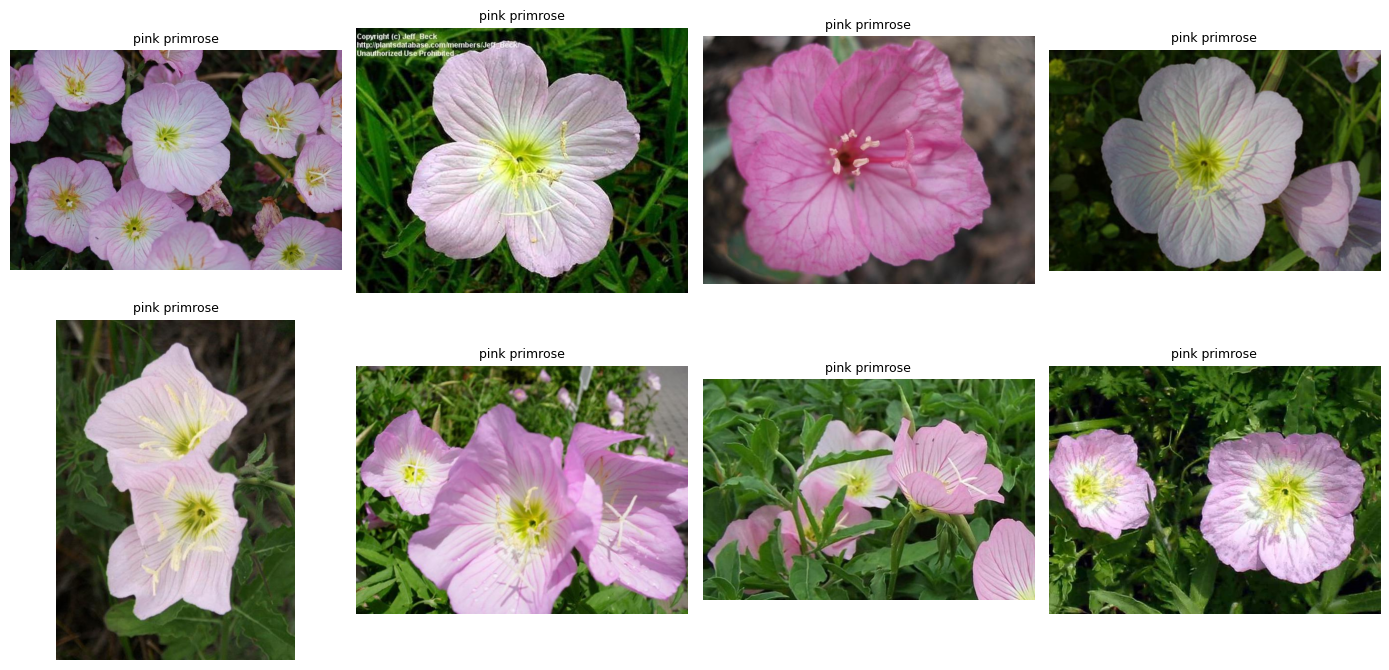

In [ ]:
# 이 셀에서 하는 일:
# - 원본 PIL 이미지를 직접 시각화합니다.
# - 아직 Tensor 변환이나 정규화가 적용되지 않은 모습입니다.

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    image, label = raw_train_dataset[i]
    ax.imshow(image)
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 3. 학습/검증/테스트 split 이해하기

이번 실습에서는 공식 split을 그대로 사용합니다.

- `train`: 모델이 실제로 가중치를 업데이트하는 데 사용
- `val`: epoch마다 성능을 점검하는 데 사용
- `test`: 마지막에 한 번만 최종 평가에 사용

이 흐름은 실제 프로젝트에서도 매우 중요합니다. test 데이터는 모델 튜닝에 사용하지 않는다는 점이 핵심입니다.


## 4. CNN baseline 준비

먼저 from-scratch baseline으로 간단한 CNN을 학습해보겠습니다.

이번 CNN은 입력 해상도가 달라져도 동작하도록 `AdaptiveAvgPool2d`를 사용합니다. 이렇게 하면 꽃 사진처럼 원본 이미지 크기가 다양한 데이터셋에도 유연하게 대응할 수 있습니다.


In [ ]:
# 이 셀에서 하는 일:
# - CNN과 MobileViT 모두 사용할 공통 이미지 크기를 정합니다.
# - CNN용 전처리를 정의합니다.

COMMON_IMAGE_SIZE = 224

cnn_train_transform = transforms.Compose([
    transforms.Resize((COMMON_IMAGE_SIZE, COMMON_IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

cnn_eval_transform = transforms.Compose([
    transforms.Resize((COMMON_IMAGE_SIZE, COMMON_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


In [ ]:
# 이 셀에서 하는 일:
# - CNN용 dataset과 dataloader를 만듭니다.
# - Flowers102 공식 split을 그대로 사용합니다.

cnn_train_dataset = datasets.Flowers102(root=DATA_ROOT, split='train', download=False, transform=cnn_train_transform)
cnn_valid_dataset = datasets.Flowers102(root=DATA_ROOT, split='val', download=False, transform=cnn_eval_transform)
cnn_test_dataset = datasets.Flowers102(root=DATA_ROOT, split='test', download=False, transform=cnn_eval_transform)

CNN_BATCH_SIZE = 32

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=2)
cnn_valid_loader = DataLoader(cnn_valid_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=2)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
# 이 셀에서 하는 일:
# - from-scratch CNN baseline 모델을 정의합니다.
# - 출력 클래스 수는 Flowers102의 102개 클래스에 맞춥니다.

def build_cnn_model(num_classes=102):
    class SimpleCNN(nn.Module):
        def __init__(self, num_classes):
            super().__init__()

            self.features = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )

            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes),
            )

        def forward(self, x):
            x = self.features(x)
            x = self.classifier(x)
            return x

    return SimpleCNN(num_classes)

cnn_model = build_cnn_model(num_classes=len(class_names)).to(device)
print(cnn_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=102, bias=True)
  )
)


In [ ]:
# 이 셀에서 하는 일:
# - 공통 학습/평가 함수를 정의합니다.
# - 모델의 forward 결과가 logits라고 가정합니다.

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate_model(model, dataloader, device, criterion=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, labels)
                running_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total if criterion is not None else None
    avg_acc = correct / total
    return avg_loss, avg_acc


In [ ]:
# 이 셀에서 하는 일:
# - CNN baseline을 학습합니다.
# - train / valid 성능을 함께 확인합니다.

cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
CNN_EPOCHS = 5

cnn_history = []

for epoch in range(CNN_EPOCHS):
    train_loss, train_acc = train_one_epoch(cnn_model, cnn_train_loader, cnn_optimizer, cnn_criterion, device)
    valid_loss, valid_acc = evaluate_model(cnn_model, cnn_valid_loader, device, cnn_criterion)

    cnn_history.append((train_loss, train_acc, valid_loss, valid_acc))

    print(
        f"[CNN Epoch {epoch + 1}/{CNN_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f}"
    )


[CNN Epoch 1/5] train_loss=4.6295, train_acc=0.0088, valid_loss=4.6022, valid_acc=0.0176
[CNN Epoch 2/5] train_loss=4.4890, train_acc=0.0069, valid_loss=4.3062, valid_acc=0.0206
[CNN Epoch 3/5] train_loss=4.2871, train_acc=0.0255, valid_loss=4.2066, valid_acc=0.0196
[CNN Epoch 4/5] train_loss=4.2349, train_acc=0.0147, valid_loss=4.1764, valid_acc=0.0216
[CNN Epoch 5/5] train_loss=4.1555, train_acc=0.0147, valid_loss=4.1409, valid_acc=0.0255


In [ ]:
# 이 셀에서 하는 일:
# - CNN baseline의 validation / test 성능을 확인합니다.

cnn_valid_loss, cnn_valid_acc = evaluate_model(cnn_model, cnn_valid_loader, device, cnn_criterion)
cnn_test_loss, cnn_test_acc = evaluate_model(cnn_model, cnn_test_loader, device, cnn_criterion)

print(f'CNN valid accuracy: {cnn_valid_acc:.4%}')
print(f'CNN test accuracy:  {cnn_test_acc:.4%}')


CNN valid accuracy: 2.5490%
CNN test accuracy:  1.5124%


## 5. Pretrained MobileViT-XSmall 이해하기

`pretrained model`은 큰 데이터셋에서 먼저 학습된 모델입니다.

여기서는 `ImageNet-1k`로 미리 학습된 `apple/mobilevit-x-small`을 사용합니다.

많은 최신 연구/개발 워크플로우에서는 이런 pretrained 모델을 먼저 불러온 뒤, 현재 문제에 맞게 마지막 분류층을 바꾸고 추가 학습을 하는 방식이 기본 출발점에 가깝습니다.
완전히 처음부터 학습하는 방식도 여전히 중요하지만, 실제 프로젝트에서는 pretrained 모델을 활용한 fine-tuning이 더 자주 선택됩니다.

조금 더 구체적으로 말하면, fine-tuning은 다음과 같은 흐름으로 이해할 수 있습니다.
- 먼저 큰 데이터셋에서 사전 학습된 모델(Pretrained Model)을 불러옵니다.
- 현재 내 문제의 클래스 수에 맞게 마지막 분류층을 바꿉니다.
- 그 다음 내 데이터셋으로 몇 epoch 더 학습해, 기존 지식을 현재 문제에 맞게 조정합니다.

핵심 아이디어는 다음과 같습니다.
- 처음부터 무작위로 시작하는 대신,
- 이미 일반적인 시각 특징을 배운 모델에서 출발하고,
- 내 데이터셋(`Flowers102`)에 맞게 조금 더 학습합니다.

이 과정을 `fine-tuning`이라고 합니다.


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT용 image processor와 pretrained 모델을 불러옵니다.
# - T4 메모리를 고려해 x-small 체크포인트를 사용합니다.

checkpoint = 'apple/mobilevit-x-small'

image_processor = AutoImageProcessor.from_pretrained(checkpoint)
mobilevit_base_model = MobileViTForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(class_names),
    ignore_mismatched_sizes=True,
).to(device)

print(image_processor)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

The image processor of type `MobileViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/9.42M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

MobileViTForImageClassification LOAD REPORT from: apple/mobilevit-x-small
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([102, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([102])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/9.35M [00:00<?, ?B/s]

MobileViTImageProcessorFast {
  "crop_size": {
    "height": 256,
    "width": 256
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_flip_channel_order": true,
  "do_flip_channels": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_processor_type": "MobileViTImageProcessorFast",
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 288
  }
}



In [ ]:
# 이 셀에서 하는 일:
# - MobileViT 모델 구조를 확인합니다.
# - 총 파라미터 수를 계산합니다.

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print(mobilevit_base_model)
print(f'총 파라미터 수: {count_parameters(mobilevit_base_model):,}')


MobileViTForImageClassification(
  (mobilevit): MobileViTModel(
    (conv_stem): MobileViTConvLayer(
      (convolution): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (normalization): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLUActivation()
    )
    (encoder): MobileViTEncoder(
      (layer): ModuleList(
        (0): MobileViTMobileNetLayer(
          (layer): ModuleList(
            (0): MobileViTInvertedResidual(
              (expand_1x1): MobileViTConvLayer(
                (convolution): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): SiLUActivation()
              )
              (conv_3x3): MobileViTConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)

## 6. MobileViT 전처리와 DataLoader 준비

Flowers102는 꽃 사진이기 때문에 배경, 크기, 자세 변화가 있습니다. pretrained model이 기대하는 입력 크기와 정규화 규칙에 맞춰 전처리를 적용해야 합니다.

이번 실습에서는 processor 설정을 참고해 전처리 규칙을 만듭니다.


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT용 입력 크기와 정규화 통계를 가져옵니다.
# - transformers 버전에 따라 size 형식이 다를 수 있으므로 안전하게 처리합니다.
# - 전처리 규칙을 정의합니다.

size_config = image_processor.size

if isinstance(size_config, dict):
    if 'height' in size_config:
        image_size = size_config['height']
    elif 'shortest_edge' in size_config:
        image_size = size_config['shortest_edge']
    elif 'width' in size_config:
        image_size = size_config['width']
    else:
        image_size = COMMON_IMAGE_SIZE
elif isinstance(size_config, (list, tuple)):
    image_size = size_config[0]
else:
    image_size = size_config if isinstance(size_config, int) else COMMON_IMAGE_SIZE

image_mean = image_processor.image_mean if image_processor.image_mean is not None else [0.5, 0.5, 0.5]
image_std = image_processor.image_std if image_processor.image_std is not None else [0.5, 0.5, 0.5]

print(f'image size: {image_size}')
print(f'image mean: {image_mean}')
print(f'image std: {image_std}')

mobilevit_train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std),
])

mobilevit_eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std),
])


image size: 288
image mean: [0.5, 0.5, 0.5]
image std: [0.5, 0.5, 0.5]


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT용 dataset과 dataloader를 만듭니다.
# - Flowers102 공식 split을 그대로 사용합니다.

mobilevit_train_dataset = datasets.Flowers102(root=DATA_ROOT, split='train', download=False, transform=mobilevit_train_transform)
mobilevit_valid_dataset = datasets.Flowers102(root=DATA_ROOT, split='val', download=False, transform=mobilevit_eval_transform)
mobilevit_test_dataset = datasets.Flowers102(root=DATA_ROOT, split='test', download=False, transform=mobilevit_eval_transform)

MOBILEVIT_BATCH_SIZE = 32

mobilevit_train_loader = DataLoader(mobilevit_train_dataset, batch_size=MOBILEVIT_BATCH_SIZE, shuffle=True, num_workers=2)
mobilevit_valid_loader = DataLoader(mobilevit_valid_dataset, batch_size=MOBILEVIT_BATCH_SIZE, shuffle=False, num_workers=2)
mobilevit_test_loader = DataLoader(mobilevit_test_dataset, batch_size=MOBILEVIT_BATCH_SIZE, shuffle=False, num_workers=2)


## 7. MobileViT supervised fine-tuning

이번 실습에서는 pretrained MobileViT를 전체적으로 fine-tuning 합니다.

즉, 모델의 가중치를 0에서 새로 배우게 하는 것이 아니라, 이미 학습되어 있는 가중치를 시작점으로 두고 `Flowers102`에 맞게 조금 더 조정합니다.
그래서 fine-tuning은 종종 `좋은 초기값에서 출발하는 학습`이라고 이해해도 됩니다.

- 학습 데이터가 아주 크지 않기 때문에 pretrained initialization의 이점을 기대할 수 있습니다.
- 모델은 pretrained 특징을 출발점으로 사용하고, 마지막 분류 문제는 `Flowers102`에 맞게 다시 적응합니다.
- 또한 이번 실습에서는 CNN baseline과 MobileViT 모두 `batch size 32`, `5 epoch`로 맞춰 비교합니다.


In [ ]:
# 이 셀에서 하는 일:
# - Hugging Face 모델을 일반 PyTorch 분류 모델처럼 사용하기 위한 래퍼를 정의합니다.
# - 이렇게 하면 CNN과 거의 같은 학습 함수를 재사용할 수 있습니다.

class HFClassifierWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, x):
        outputs = self.hf_model(pixel_values=x)
        return outputs.logits

mobilevit_model = HFClassifierWrapper(mobilevit_base_model).to(device)


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT fine-tuning에 사용할 손실 함수와 옵티마이저를 정의합니다.

mobilevit_criterion = nn.CrossEntropyLoss()
mobilevit_optimizer = torch.optim.AdamW(mobilevit_model.parameters(), lr=5e-5)
MOBILEVIT_EPOCHS = 5

print(f'MobileViT 학습 epoch 수: {MOBILEVIT_EPOCHS}')


MobileViT 학습 epoch 수: 5


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT를 실제로 fine-tuning 합니다.
# - train / valid 성능을 함께 기록합니다.

mobilevit_history = []

for epoch in range(MOBILEVIT_EPOCHS):
    train_loss, train_acc = train_one_epoch(mobilevit_model, mobilevit_train_loader, mobilevit_optimizer, mobilevit_criterion, device)
    valid_loss, valid_acc = evaluate_model(mobilevit_model, mobilevit_valid_loader, device, mobilevit_criterion)

    mobilevit_history.append((train_loss, train_acc, valid_loss, valid_acc))

    print(
        f"[MobileViT Epoch {epoch + 1}/{MOBILEVIT_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f}"
    )


[MobileViT Epoch 1/5] train_loss=4.6198, train_acc=0.0118, valid_loss=4.5925, valid_acc=0.0284
[MobileViT Epoch 2/5] train_loss=4.5631, train_acc=0.0637, valid_loss=4.5461, valid_acc=0.0843
[MobileViT Epoch 3/5] train_loss=4.5067, train_acc=0.1667, valid_loss=4.4941, valid_acc=0.1667
[MobileViT Epoch 4/5] train_loss=4.4445, train_acc=0.2627, valid_loss=4.4339, valid_acc=0.2539
[MobileViT Epoch 5/5] train_loss=4.3740, train_acc=0.3745, valid_loss=4.3612, valid_acc=0.3284


In [ ]:
# 이 셀에서 하는 일:
# - MobileViT의 validation / test 성능을 확인합니다.

mobilevit_valid_loss, mobilevit_valid_acc = evaluate_model(mobilevit_model, mobilevit_valid_loader, device, mobilevit_criterion)
mobilevit_test_loss, mobilevit_test_acc = evaluate_model(mobilevit_model, mobilevit_test_loader, device, mobilevit_criterion)

print(f'MobileViT valid accuracy: {mobilevit_valid_acc:.4%}')
print(f'MobileViT test accuracy:  {mobilevit_test_acc:.4%}')


MobileViT valid accuracy: 32.8431%
MobileViT test accuracy:  28.3623%


## 8. 성능 비교표

이제 같은 데이터 조건에서 두 모델의 성능을 비교합니다.

이번 비교에서는 `train/valid/test split`, `batch size`, `epoch 수`, `평가 지표(accuracy)` 같은 기본 비교 조건을 맞춘 상태에서, `from-scratch 학습`과 `pretrained fine-tuning`의 차이를 관찰합니다.


In [ ]:
# 이 셀에서 하는 일:
# - CNN baseline과 MobileViT SFT의 성능을 표 형태로 정리합니다.

comparison_rows = [
    ('CNN from scratch', cnn_valid_acc, cnn_test_acc),
    ('MobileViT-XSmall pretrained + SFT', mobilevit_valid_acc, mobilevit_test_acc),
]

print(f"{'Model':40s} | {'Valid Acc':>10s} | {'Test Acc':>10s}")
print('-' * 68)

for model_name, valid_acc, test_acc in comparison_rows:
    print(f"{model_name:40s} | {valid_acc:10.4%} | {test_acc:10.4%}")


Model                                    |  Valid Acc |   Test Acc
--------------------------------------------------------------------
CNN from scratch                         |    2.5490% |    1.5124%
MobileViT-XSmall pretrained + SFT        |   32.8431% |   28.3623%


## Appendix. ResNet18 scratch 비교

이 섹션은 선택 실험입니다.

본편의 핵심 메시지는 `CNN scratch vs MobileViT pretrained + SFT` 비교였지만, 추가로 `ResNet18 scratch`도 같은 조건에서 학습해보면 다음 질문에 답할 수 있습니다.

- 구조가 더 좋은 CNN 계열 모델은 얼마나 유리한가?
- pretrained 효과와 아키텍처 효과를 어떻게 구분해서 볼 수 있는가?

이번 appendix에서 학습에 사용된 ResNet18은 본편과 같은 `batch size 32`, `5 epoch` 조건으로 맞춰 학습합니다.


In [ ]:
# 이 셀에서 하는 일:
# - ResNet18 scratch 모델을 정의합니다.
# - pretrained weight는 사용하지 않고, Flowers102 분류용 출력층만 맞춥니다.

resnet18_model = models.resnet18(weights=None)
resnet18_model.fc = nn.Linear(resnet18_model.fc.in_features, len(class_names))
resnet18_model = resnet18_model.to(device)

print(resnet18_model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 이 셀에서 하는 일:
# - ResNet18 scratch 학습에 사용할 손실 함수와 옵티마이저를 정의합니다.
# - epoch 수는 CNN baseline과 동일하게 맞춥니다.

resnet18_criterion = nn.CrossEntropyLoss()
resnet18_optimizer = torch.optim.Adam(resnet18_model.parameters(), lr=1e-3)
RESNET18_EPOCHS = CNN_EPOCHS

print(f'ResNet18 학습 epoch 수: {RESNET18_EPOCHS}')


ResNet18 학습 epoch 수: 5


In [ ]:
# 이 셀에서 하는 일:
# - ResNet18 scratch를 학습합니다.
# - 입력 전처리와 DataLoader는 CNN과 동일한 것을 사용합니다.

resnet18_history = []

for epoch in range(RESNET18_EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet18_model, cnn_train_loader, resnet18_optimizer, resnet18_criterion, device)
    valid_loss, valid_acc = evaluate_model(resnet18_model, cnn_valid_loader, device, resnet18_criterion)

    resnet18_history.append((train_loss, train_acc, valid_loss, valid_acc))

    print(
        f"[ResNet18 Epoch {epoch + 1}/{RESNET18_EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f}"
    )


[ResNet18 Epoch 1/5] train_loss=4.6204, train_acc=0.0314, valid_loss=5.1543, valid_acc=0.0373
[ResNet18 Epoch 2/5] train_loss=3.8984, train_acc=0.0824, valid_loss=4.5850, valid_acc=0.0647
[ResNet18 Epoch 3/5] train_loss=3.5593, train_acc=0.1167, valid_loss=3.8968, valid_acc=0.0990
[ResNet18 Epoch 4/5] train_loss=3.4017, train_acc=0.1294, valid_loss=3.6902, valid_acc=0.1167
[ResNet18 Epoch 5/5] train_loss=3.2253, train_acc=0.1686, valid_loss=3.9542, valid_acc=0.1186


In [ ]:
# 이 셀에서 하는 일:
# - ResNet18 scratch의 validation / test 성능을 확인합니다.

resnet18_valid_loss, resnet18_valid_acc = evaluate_model(resnet18_model, cnn_valid_loader, device, resnet18_criterion)
resnet18_test_loss, resnet18_test_acc = evaluate_model(resnet18_model, cnn_test_loader, device, resnet18_criterion)

print(f'ResNet18 valid accuracy: {resnet18_valid_acc:.4%}')
print(f'ResNet18 test accuracy:  {resnet18_test_acc:.4%}')


ResNet18 valid accuracy: 11.8627%
ResNet18 test accuracy:  9.6113%


## Appendix 비교표

이제 본편의 두 모델에 `ResNet18 scratch`를 추가해 함께 비교합니다.

이 표는 세 모델을 같은 데이터 split과 같은 기본 비교 조건에서 나란히 비교하지만, `ResNet18 scratch`와 `MobileViT pretrained + SFT`는 모델 구조와 사전학습 여부가 동시에 다르기 때문에 해석 시 그 점을 함께 고려해야 합니다.


In [ ]:
# 이 셀에서 하는 일:
# - CNN, ResNet18 scratch, MobileViT SFT를 함께 비교합니다.

appendix_rows = [
    ('CNN from scratch', cnn_valid_acc, cnn_test_acc),
    ('ResNet18 from scratch', resnet18_valid_acc, resnet18_test_acc),
    ('MobileViT-XSmall pretrained + SFT', mobilevit_valid_acc, mobilevit_test_acc),
]

print(f"{'Model':40s} | {'Valid Acc':>10s} | {'Test Acc':>10s}")
print('-' * 68)

for model_name, valid_acc, test_acc in appendix_rows:
    print(f"{model_name:40s} | {valid_acc:10.4%} | {test_acc:10.4%}")


Model                                    |  Valid Acc |   Test Acc
--------------------------------------------------------------------
CNN from scratch                         |    2.5490% |    1.5124%
ResNet18 from scratch                    |   11.8627% |    9.6113%
MobileViT-XSmall pretrained + SFT        |   32.8431% |   28.3623%


## 마무리 정리

이번 실습에서 확인할 핵심은 다음과 같습니다.

- 최근 딥러닝 워크플로우에서는 scratch 학습만을 기본값으로 두기보다, pretrained 모델을 출발점으로 fine-tuning 하는 접근이 매우 널리 사용됩니다.
- `Flowers102`는 pretrained model의 효과를 살펴보기 좋은 대표적인 꽃 분류 데이터셋입니다.
- 같은 데이터 split과 같은 기본 비교 조건에서 비교하면, `from-scratch 학습`과 `pretrained fine-tuning`의 차이를 더 분명하게 볼 수 있습니다.
- 단순 CNN, 더 강한 CNN 계열 구조(ResNet18), pretrained MobileViT를 함께 보면 `모델 구조의 차이`와 `사전학습의 효과`를 나눠 생각해볼 수 있습니다.
- pretrained model을 사용할 때는 모델 구조뿐 아니라 입력 크기와 정규화 규칙도 함께 맞춰야 합니다.
- 실무에서는 여기서 더 나아가 augmentation 강화, scheduler, mixed precision, early stopping 등을 추가할 수 있습니다.

### 결과 해석 가이드
- 단순 CNN이 낮은 성능을 보인다면, 작은 실제 이미지 데이터셋에서 scratch 학습이 쉽지 않다는 뜻으로 해석할 수 있습니다.
- ResNet18 scratch가 CNN보다 좋아진다면, 더 좋은 아키텍처가 성능 향상에 기여했음을 보여줍니다.
- MobileViT pretrained + SFT가 더 좋은 결과를 보인다면, 사전학습된 시각 특징이 작은 데이터셋에서 유리한 출발점이 될 수 있음을 시사합니다.

### 다음 확장 아이디어
- `CNN`, `ResNet18 scratch`, `MobileViT-XSmall SFT`의 epoch 수를 함께 늘려 성능 변화 추이를 비교해보기
- `RandomResizedCrop`, `ColorJitter` 같은 augmentation을 추가해 Flowers102에서 일반화 성능이 어떻게 바뀌는지 확인해보기
- MobileViT에서 전체 fine-tuning 대신 `분류 head만 학습`하거나, 일부 블록만 unfreeze 해서 비교해보기
- `ResNet18 pretrained`를 추가해 `좋은 아키텍처의 scratch 학습`과 `pretrained fine-tuning` 차이를 더 직접적으로 비교해보기
- `train + val`을 합쳐 최종 학습용 데이터로 쓰고, test set만 남겨 최종 성능을 다시 측정해보기
